### <font color="green"> ***Genetic drift by lineage*** </font>

* Genetic drift reduces parental lineages over time, eventually down to a single ancestral lineage
* The lost of lineages over time occurs by chance not by natural selection
* The lost of genetic diversity affects all genomic loci (unlike natural selection, which tends to act on a specific locus)
* The smaller the population size, the faster fixation occurs




In [3]:
import random
def genetic_drift(N, gen_max = 100, debug = False):
    """ genetic drift of a haploid population with N individuals
        gen_max: the maximum number of generations
        simulation stops when a single ancestral lineage remains (or the gen_max is reached)
    """
    pop = range(N) # ancestral linages labeled as 0 through N-1
    out = []
    for g in range(gen_max):
        pop = random.choices(pop, k=N) # resample from the parental population (not shuffle) and overwrite pop
        # count the distinct number of lineages
        num_lineages = len(set(pop))
        if debug is True:
            print("gen:\t", g, "; lineage count:\t", num_lineages)
        if num_lineages == 1: # Fixation: A is either lost or fixed
          break
        out.append({"pop_size": N, "gen": g, "num_lineages": num_lineages}) # save record as a list of dictionary
    return(out)


In [7]:
# simulate 5 pops with increasing pop sizes
# both wth equal frequences of alleles to start, p=0.5 (frequency of the derived allele)
import pandas as pd
out_list = []
for N in [50, 100, 200, 500, 1000]:
    out_list.append(pd.DataFrame(genetic_drift(N, 1000)))
df = pd.concat(out_list, ignore_index=True)
print(df.head())
print(df.shape)

   pop_size  gen  num_lineages
0        50    0            29
1        50    1            23
2        50    2            19
3        50    3            14
4        50    4            13
(2964, 3)


pop_size
50      AxesSubplot(0.125,0.11;0.775x0.77)
100     AxesSubplot(0.125,0.11;0.775x0.77)
200     AxesSubplot(0.125,0.11;0.775x0.77)
500     AxesSubplot(0.125,0.11;0.775x0.77)
1000    AxesSubplot(0.125,0.11;0.775x0.77)
Name: num_lineages, dtype: object

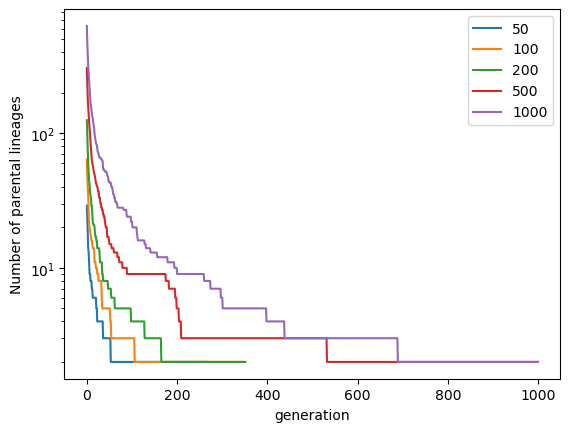

In [8]:
df.set_index('gen', inplace=True)
df.groupby('pop_size')['num_lineages'].plot(legend=True, logy = True, xlabel='generation', ylabel='Number of parental lineages')

### <font color="green"> ***Hunter PTC locus diversity does not fit HWE expectations*** </font>

* Hypthesis testing by simulations
* Calculate the observed allele frequencies and heterozygosity (H) based on the experimental data 
* Simulate a diploid population with the same sample size and the same allele frequencies
* Compare $H_{obs}$ with the distribution of $H_{exp}$
* Obtain the empirical p value (significance, or the probability of H by chance)

In [23]:
def H_obs(ct_11, ct_10, ct_00):
    """ genotypes are three tuples
        return heterozygosity as the proportion of heterozygotes
    """
    sum_ind = ct_11 + ct_10 + ct_00
    freq_1 = (2 * ct_11 + ct_10)/(2*sum_ind)
    return({"H":ct_10/sum_ind, "p": freq_1, "pop_size": sum_ind})

In [24]:
obs = H_obs(70, 29, 91)
obs

{'H': 0.15263157894736842, 'p': 0.44473684210526315, 'pop_size': 190}

In [28]:
import numpy as np
def sim_HWE(N, p):
    """The population consists of N diploid individuals.

      Each individual has two chromosomes, containing
      allele "1" or "0", with probability p or 1-p,
      respectively.

      The population is a list of tuples.
      """
    population = []
    for i in range(N):
        # set allele 1 as A or a (with prob of p)
        allele1 = '0'
        if np.random.uniform() < p:
            allele1 = '1'

        # set allele 2 as A or a (with prob of p)
        allele2 = '0'
        if np.random.uniform() < p:
            allele2 = '1'
        # a dipolid individual as a tuple
        population.append((allele1, allele2))
    stats = H_obs(population.count(("0", "0")), population.count(("0", "1")) + population.count(("1", "0")), population.count(("1", "1")))
    return(stats['H'])

dip_pop = sim_HWE(obs['pop_size'], obs['p'])
print(dip_pop)

0.5157894736842106


In [31]:
out_list = [{'H': obs['H'], 'class': 'obs'}] # observed
for i in range(1000):
    het = sim_HWE(obs['pop_size'], obs['p'])
    out_list.append({'H': het, 'class': 'sim'})

df = pd.DataFrame(out_list)
print(df.head())
print(df.shape)

          H class
0  0.152632   obs
1  0.426316   sim
2  0.500000   sim
3  0.568421   sim
4  0.531579   sim
(1001, 2)


array([[<AxesSubplot: title={'center': 'H'}>]], dtype=object)

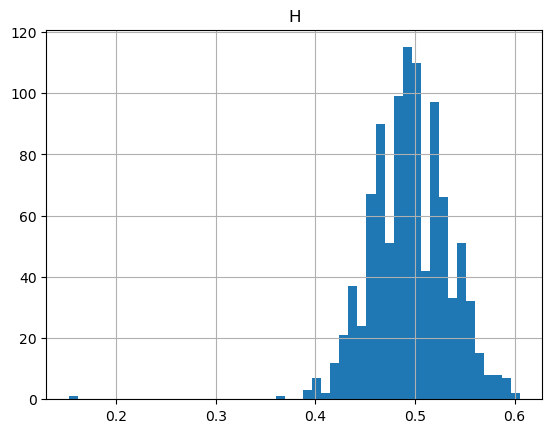

In [34]:
df.hist(bins = 50)